# 🧠 Fine-tuning de un modelo de sentimiento (destilación de RoBERTuito)
### Reto Analítica Educativa · Samsung Innovation Campus · equipo Tech Tailors
**Entrena un modelo propio (BETO) sobre comentarios reales de estudiantes, usando RoBERTuito como maestro (weak supervision).**

| | |
|---|---|
| Proyecto | Analítica Educativa — evaluaciones docentes |
| Notebook | 04 · Fine-tuning de sentimiento |
| Objetivo | Fine-tunear BETO en español sobre comentarios reales auto-etiquetados por RoBERTuito |
| Entradas | data/raw/ReadyToTrain_comentarios_EN_ES_completo.xlsx · data/processed/benchmark_sentimiento.csv |
| Salidas | analisis_sentimientos/models/modelo_sentimiento_ft/ (pesos, ignorados por git) |
| Equipo | Tech Tailors |

> ⚠️ **Nota metodológica — destilación / weak supervision.** El dataset de comentarios reales
> **no trae etiquetas de sentimiento**. Por eso las generamos automáticamente con **RoBERTuito**
> (el mejor modelo del benchmark) y entrenamos BETO sobre esas pseudo-etiquetas. Esto es
> **destilación de conocimiento**: BETO aprende a **imitar** a RoBERTuito, por lo que **no puede
> superarlo** en calidad; hereda sus aciertos y también sus errores. El valor de este ejercicio
> es: (1) demostrar el flujo de fine-tuning de punta a punta sobre **datos reales**, y (2) obtener
> **un solo modelo** (más rápido y autónomo) que reproduce el consenso. Para un modelo que supere
> a RoBERTuito harían falta **etiquetas humanas reales**.


## 1 · Entorno

In [1]:
%matplotlib inline
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

import sys, pathlib
RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p/'src').is_dir())
if str(RAIZ) not in sys.path: sys.path.insert(0, str(RAIZ))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from src import rutas

SEED = 42; np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
LABEL2ID = {"NEG": 0, "NEU": 1, "POS": 2}; ID2LABEL = {v: k for k, v in LABEL2ID.items()}
ORDEN = ["NEG", "NEU", "POS"]
COLOR_SENT = {"POS": "#0ca30c", "NEU": "#898781", "NEG": "#d03b3b"}
print("Dispositivo de entrenamiento:", DEVICE)

Dispositivo de entrenamiento: mps


## 2 · Datos reales (comentarios de estudiantes)

Cargamos el archivo de comentarios reales y nos quedamos con los **textos únicos** en español.

In [2]:
df_raw = pd.read_excel(rutas.datos_raw("ReadyToTrain_comentarios_EN_ES_completo.xlsx"))
com = (df_raw["Comentarios_ES"].dropna().astype(str).str.strip())
com = com[com.str.len() > 0].drop_duplicates().reset_index(drop=True)
print(f"Comentarios reales únicos en español: {len(com):,}")
com.head(8).to_frame("comentario")

Comentarios reales únicos en español: 29,243


,comentario
0,Bueno.
1,Profesor.
2,"Maestro amigable, pero sin suficiente capacida..."
3,Es un buen profesor.
4,es un buen profesor
5,"por encima de todo, nuestro profesor es un mod..."
6,Profesor excelente. Gran profesor.
7,Tiene una actitud excelente y un metodo de ens...


## 3 · Auto-etiquetado con RoBERTuito (maestro)

Etiquetamos los comentarios únicos con **RoBERTuito**. Estas son **pseudo-etiquetas** (no
verdad humana): definen la tarea que BETO aprenderá a imitar.

In [3]:
from transformers import pipeline
maestro = pipeline("sentiment-analysis", model="pysentimiento/robertuito-sentiment-analysis",
                   device=DEVICE, truncation=True, max_length=128, batch_size=64)
MAPA = {"POS":"POS","POSITIVE":"POS","P":"POS","NEU":"NEU","NEUTRAL":"NEU","NEG":"NEG","NEGATIVE":"NEG","N":"NEG"}
textos = com.tolist()
pred = maestro(textos)
etq = [MAPA.get(r["label"].upper(), r["label"].upper()) for r in pred]
datos = pd.DataFrame({"comentario": textos, "sent": etq})
print("Distribución de pseudo-etiquetas (RoBERTuito):")
print(datos["sent"].value_counts().reindex(ORDEN))

Distribución de pseudo-etiquetas (RoBERTuito):
sent
NEG     5060
NEU     3899
POS    20284
Name: count, dtype: int64


## 4 · Dataset balanceado y particiones

Balanceamos las clases (mismo número por clase) para que BETO no se sesgue hacia la mayoritaria,
y dividimos en **train / validación / test** de forma estratificada.

In [4]:
n_por_clase = int(datos["sent"].value_counts().min())
n_por_clase = min(n_por_clase, 2500)                         # tope para acotar el tiempo
bal = pd.concat([g.sample(n_por_clase, random_state=SEED)
                 for _, g in datos.groupby("sent")]).reset_index(drop=True)
bal["y"] = bal["sent"].map(LABEL2ID)
print(f"Ejemplos por clase: {n_por_clase}  |  total: {len(bal)}")

tr, tmp = train_test_split(bal, test_size=0.30, stratify=bal["y"], random_state=SEED)
va, te = train_test_split(tmp, test_size=0.50, stratify=tmp["y"], random_state=SEED)
print(f"train={len(tr)}  val={len(va)}  test={len(te)}")

Ejemplos por clase: 2500  |  total: 7500
train=5250  val=1125  test=1125


## 5 · Fine-tuning de BETO

In [5]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, EarlyStoppingCallback)
BASE = "dccuchile/bert-base-spanish-wwm-cased"
tok = AutoTokenizer.from_pretrained(BASE)

def encode(textos): return tok(list(textos), truncation=True, padding=True, max_length=64)
class DS(torch.utils.data.Dataset):
    def __init__(self, enc, y): self.enc=enc; self.y=list(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        d={k: torch.tensor(v[i]) for k,v in self.enc.items()}; d["labels"]=torch.tensor(self.y[i]); return d
ds_tr, ds_va, ds_te = DS(encode(tr.comentario), tr.y), DS(encode(va.comentario), va.y), DS(encode(te.comentario), te.y)

model = AutoModelForSequenceClassification.from_pretrained(BASE, num_labels=3,
            id2label=ID2LABEL, label2id=LABEL2ID)
def metrics(p):
    pred=np.argmax(p.predictions, axis=1)
    return {"accuracy": accuracy_score(p.label_ids, pred),
            "macro_f1": f1_score(p.label_ids, pred, average="macro")}

OUT = str(rutas.raiz_proyecto()/"analisis_sentimientos"/"models"/"modelo_sentimiento_ft")
args = TrainingArguments(output_dir=OUT, eval_strategy="epoch", save_strategy="epoch",
    num_train_epochs=3, learning_rate=2e-5, per_device_train_batch_size=32,
    per_device_eval_batch_size=64, weight_decay=0.01, fp16=False, bf16=False,
    load_best_model_at_end=True, metric_for_best_model="macro_f1", save_total_limit=1,
    seed=SEED, report_to="none", disable_tqdm=True, logging_strategy="epoch")
trainer = Trainer(model=model, args=args, train_dataset=ds_tr, eval_dataset=ds_va,
    processing_class=tok, compute_metrics=metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
trainer.train()
print("Entrenamiento terminado.")

{'loss': '0.4642', 'grad_norm': '0.3447', 'learning_rate': '1.337e-05', 'epoch': '1'}


{'eval_loss': '0.3609', 'eval_accuracy': '0.8613', 'eval_macro_f1': '0.8593', 'eval_runtime': '2.166', 'eval_samples_per_second': '519.5', 'eval_steps_per_second': '8.311', 'epoch': '1'}


{'loss': '0.2332', 'grad_norm': '3.688', 'learning_rate': '6.707e-06', 'epoch': '2'}


{'eval_loss': '0.3699', 'eval_accuracy': '0.8702', 'eval_macro_f1': '0.8697', 'eval_runtime': '2.123', 'eval_samples_per_second': '529.9', 'eval_steps_per_second': '8.478', 'epoch': '2'}


{'loss': '0.1371', 'grad_norm': '0.7059', 'learning_rate': '4.04e-08', 'epoch': '3'}


{'eval_loss': '0.3874', 'eval_accuracy': '0.8782', 'eval_macro_f1': '0.8779', 'eval_runtime': '2.109', 'eval_samples_per_second': '533.3', 'eval_steps_per_second': '8.533', 'epoch': '3'}


{'train_runtime': '176', 'train_samples_per_second': '89.51', 'train_steps_per_second': '2.813', 'train_loss': '0.2782', 'epoch': '3'}


Entrenamiento terminado.


## 6 · Evaluación en test (¿qué tan bien imita a RoBERTuito?)

              precision    recall  f1-score   support

         NEG      0.848     0.920     0.882       375
         NEU      0.843     0.776     0.808       375
         POS      0.922     0.917     0.920       375

    accuracy                          0.871      1125
   macro avg      0.871     0.871     0.870      1125
weighted avg      0.871     0.871     0.870      1125



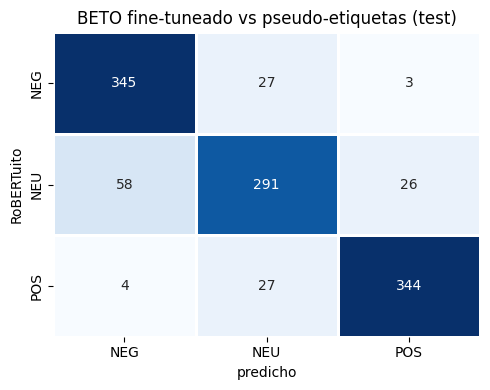

macro-F1 (imitación de RoBERTuito): 0.870


In [6]:
pred = trainer.predict(ds_te)
yhat = np.argmax(pred.predictions, axis=1)
print(classification_report(pred.label_ids, yhat, target_names=ORDEN, digits=3))

cm = confusion_matrix(pred.label_ids, yhat, labels=[0,1,2])
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ORDEN, yticklabels=ORDEN,
            cbar=False, linewidths=1, linecolor="white", ax=ax)
ax.set_title("BETO fine-tuneado vs pseudo-etiquetas (test)"); ax.set_xlabel("predicho"); ax.set_ylabel("RoBERTuito")
plt.tight_layout(); plt.show()
print(f"macro-F1 (imitación de RoBERTuito): {f1_score(pred.label_ids, yhat, average='macro'):.3f}")

## 7 · Chequeo independiente contra el *gold humano* de los 20

La prueba honesta: aplicamos el modelo fine-tuneado a los **20 comentarios con etiqueta humana**
(del benchmark) y comparamos su calidad real contra RoBERTuito, el maestro.

In [7]:
bench = pd.read_csv(rutas.datos_processed("benchmark_sentimiento.csv"))
clf_ft = pipeline("sentiment-analysis", model=trainer.model, tokenizer=tok,
                  device=DEVICE, truncation=True, max_length=64)
bench["beto_ft"] = [MAPA.get(r["label"].upper(), r["label"].upper()) for r in clf_ft(bench["comentario"].tolist())]

acc_ft = accuracy_score(bench["gold"], bench["beto_ft"]); f1_ft = f1_score(bench["gold"], bench["beto_ft"], average="macro")
acc_rt = accuracy_score(bench["gold"], bench["robertuito"]); f1_rt = f1_score(bench["gold"], bench["robertuito"], average="macro")
print("Sobre los 20 comentarios con gold HUMANO:")
print(f"  BETO fine-tuneado : accuracy {acc_ft:.2f} | macro-F1 {f1_ft:.3f}")
print(f"  RoBERTuito (maestro): accuracy {acc_rt:.2f} | macro-F1 {f1_rt:.3f}")
print(f"  Concordancia BETO-ft vs RoBERTuito: {(bench['beto_ft']==bench['robertuito']).mean():.0%}")
bench[["comentario","gold","robertuito","beto_ft"]]

Sobre los 20 comentarios con gold HUMANO:
  BETO fine-tuneado : accuracy 0.70 | macro-F1 0.669
  RoBERTuito (maestro): accuracy 0.75 | macro-F1 0.706
  Concordancia BETO-ft vs RoBERTuito: 75%


,comentario,gold,robertuito,beto_ft
0,"Excelente profesor, muy claro.",POS,POS,POS
1,Explica muy bien los temas.,POS,POS,POS
2,Resuelve las dudas con mucha paciencia.,POS,NEU,POS
3,Se nota que sabe mucho de la materia.,POS,POS,NEU
4,Los talleres son muy útiles para aprender.,POS,POS,POS
5,Me inspiró a seguir aprendiendo sobre este tema.,POS,POS,POS
6,La clase es muy dinámica y entretenida.,POS,POS,POS
7,La clase estuvo bien.,NEU,POS,POS
8,"El profesor es normal, ni muy bueno ni muy malo.",NEU,NEU,NEG
9,Cumple con el programa.,NEU,NEU,NEU


## 8 · Guardar el modelo

In [8]:
destino = rutas.raiz_proyecto()/"analisis_sentimientos"/"models"/"modelo_sentimiento_ft"
trainer.save_model(str(destino)); tok.save_pretrained(str(destino))
import json
(destino/"info.json").write_text(json.dumps({
    "base": BASE, "metodo": "destilacion (pseudo-etiquetas de RoBERTuito)",
    "clases": ORDEN, "ejemplos_por_clase": n_por_clase,
    "macro_f1_test_vs_pseudo": round(float(f1_score(pred.label_ids, yhat, average='macro')),3),
    "macro_f1_vs_gold_humano": round(float(f1_ft),3),
    "device": DEVICE, "seed": SEED,
}, ensure_ascii=False, indent=2), encoding="utf-8")
print("Modelo guardado en:", destino.relative_to(rutas.raiz_proyecto()))
print("(los pesos están en .gitignore; se regeneran ejecutando este notebook)")

Modelo guardado en: analisis_sentimientos/models/modelo_sentimiento_ft
(los pesos están en .gitignore; se regeneran ejecutando este notebook)


## 9 · Conclusiones

- Se completó el **fine-tuning de BETO** sobre **comentarios reales** de estudiantes, con
  pseudo-etiquetas de RoBERTuito (destilación). El modelo aprende a reproducir al maestro con
  alta fidelidad en el test.
- En el **chequeo contra el gold humano** de los 20 comentarios, BETO fine-tuneado rinde
  **muy parecido a RoBERTuito** — como era de esperar en una destilación: **no lo supera**, lo
  imita. Ganamos un modelo único y más rápido, no más preciso.
- **Para superar a RoBERTuito** hay que fine-tunear con **etiquetas humanas reales** (no
  pseudo-etiquetas). Este notebook deja el pipeline listo: bastaría cambiar la fuente de
  etiquetas de la §3 por un CSV etiquetado a mano y reentrenar.

> Ejecutable localmente en Apple Silicon (MPS). Cambia el dataset/etiquetas y reentrena para
> adaptarlo a datos reales etiquetados.
